## Import necessary libraries

In [1]:
import glob
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil
import torch
import torchvision.transforms as T
import random
from torch.utils.data import Dataset, DataLoader
import torchvision.utils as vutils
from tqdm import tqdm

### Create necessary functions to create dataset form local storage

In [2]:
# Read the dataset path
def read_data_path(path):
    files = glob.glob(f'{path}/*/*.jpg', recursive=True)
    return files

In [3]:
# After getting the list of imafes path from previous step, make a dataframe for each image path and their corresponding label.
def make_data_csv(image_path_list, transform_data=False):
    labels = []
    transform = []

    for file_path in image_path_list:
        class_name = os.path.basename(os.path.dirname(file_path))
        labels.append(class_name)
        
        if transform_data:
            transform.append(os.path.basename(file_path).split('_')[0])
            
    data_dict = {"Images": image_path_list, "Labels": labels, "Transform" : transform} if transform_data else {"Images": image_path_list, "Labels": labels}
    dataset = pd.DataFrame(data_dict)
        
    return dataset


In [4]:
files = read_data_path(path="C:/Non-work/ML/Nepali-liscence-number-recognition/Dataset/images")

In [5]:
dataset_df = make_data_csv(image_path_list=files)

In [6]:
# Read images from path
def read_images(image_path, size=()):
    image = Image.open(image_path)
    if len(size)>0:
        image = image.resize(size)
    return image    

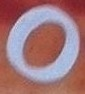

In [7]:
image_sample = read_images(files[0])
image_sample

## Data augumentation
It is the process to augument the data in cases where there are less data or the class is imbalanced.
Here, we have created a function to change the color of an image to augument the data. We change the color of each image until the data points for each label reaches similar quantity.

In [8]:
brightness = T.ColorJitter(brightness=0.2, hue=0.2)
contrast = T.ColorJitter(contrast=10)
rotate = T.RandomRotation(degrees=(15,45))
pers = T.RandomPerspective(distortion_scale=0.2,p=1)
blur = T.GaussianBlur(kernel_size=7, sigma=(0.7, 2.0))
transformation_list=[brightness, contrast, rotate, blur, pers]
# T.Grayscale()(image_path)

In [9]:
# Function to augument the images and store it in new path.
def augument_dataset(orgi_dataset,augument_path, verbose=False):
    if not os.path.exists(augument_path):
        os.makedirs(augument_path)
        
    classes = dict(orgi_dataset.Labels.value_counts())
    final_aug_value = 500
    if verbose:
        count_range = tqdm(classes.items())

    for key, value in count_range:
        
        matched_label = orgi_dataset.loc[orgi_dataset["Labels"] == key]
        matched_images_list = matched_label["Images"].to_list()
        count_diff = final_aug_value - value
        
        if verbose:    
            count_range.set_description(f"Working on adding {count_diff} for label: {key}")
        else:
            count_range = range(count_diff)

        for i in range(count_diff):
            transformation = random.choice(transformation_list)
            image_path = random.choice(matched_images_list)
            split_char = "\\"            # use "/" in linux and "\\" in windows
            filename = f"{transformation._get_name()}_{image_path.split(split_char)[-1]}"
            class_name = str(key)
            dst_path = f"{augument_path}/{class_name}/{i}_{filename}"
            
            if verbose:
                count_range.set_postfix_str(f"Transformation: {transformation._get_name()}")
            
            if not os.path.exists(augument_path+ "/" + str(class_name)):
                os.makedirs(augument_path+ "/" + str(class_name))
                
            image = read_images(image_path)
            transformed_image = transformation(image)
            transformed_image.save(dst_path)

In [10]:
path = "C:/Non-work/ML/Nepali-liscence-number-recognition/Dataset/Transformed/"
augument_dataset(orgi_dataset = dataset_df, augument_path=path, verbose=True)

Working on adding 404 for label: 0: 100%|███████████████████████████████████████████| 12/12 [01:24<00:00,  7.02s/it, Transformation: ColorJitter]


In [11]:
augumented_path = "C:/Non-work/ML/Nepali-liscence-number-recognition/Dataset/Transformed"
augumented_files = read_data_path(path=augumented_path)
aug_dataset_df = make_data_csv(image_path_list=augumented_files, transform_data=True)

In [12]:
frames = [dataset_df,aug_dataset_df[['Images','Labels']]]
new_df = pd.concat(frames)
new_df.Labels.value_counts()

0     500
1     500
2     500
3     500
4     500
5     500
6     500
7     500
8     500
9     500
ba    500
pa    500
Name: Labels, dtype: int64

## Data Pre-processing

Data pre-processing consists of several steps. 
1. First we create the one hot encoded label of each class. 
2. Then we create train set and test set.
3. We create data loader for both sets to be passed on model for training, fine-tuning or prediction.

#### Create one hot encoded label

In [13]:
from sklearn.preprocessing import LabelBinarizer
import numpy as np
from sklearn.preprocessing import OneHotEncoder

In [14]:
# Find the unique labels in whole dataset
unique_labels = new_df["Labels"].unique().tolist()

# Function to convert labels to one hot encoded label
def find_boolean_labels(data, unique_labels, label_name):
        labels = []
        for items in data[label_name]:
            map_array = np.zeros(len(unique_labels), dtype=int)
            for idx, label in enumerate(unique_labels):
                for item in items.split(","):
                    if label == item:
                        map_array[idx] = 1
            labels.append(list(map_array))
        data["one_hot_encoded_labels"] = labels

        return data


In [15]:
new_data = find_boolean_labels(new_df, unique_labels, "Labels")

#### Create Train and Test set

In [19]:
X = new_data.drop(columns="one_hot_encoded_labels")
y=new_data["one_hot_encoded_labels"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

#### Create Dataloaders for both sets

In [16]:
class HandWrittenImageDataset(Dataset):
    def __init__(self, dataframe, transform=None, num_images=None):
        self.dataset = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img_path = self.dataset.iloc[idx]["Images"]
#         one_hot_label = self.dataset.iloc[idx]["one_hot_encoded_labels"]
        one_hot_label = torch.tensor(self.dataset.iloc[idx]["one_hot_encoded_labels"])
        label = self.dataset.iloc[idx]["Labels"]
        img = Image.open(img_path)

        if self.transform:
            img = self.transform(img)

        return img, one_hot_label, label


In [17]:
transform = T.Compose([
    T.Resize((64,64)),  # Resize image to 28x28
    T.Grayscale(),  # Convert image to grayscale
    T.ToTensor(),  # Convert image to tensor
    T.Normalize((0.5,), (0.5,))  # Normalize image
])

In [21]:
# Create train dataloader
train_dataset = HandWrittenImageDataset(train_data, transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Create test datalaoder
test_dataset = HandWrittenImageDataset(test_data, transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [ ]:
# # Iterate over the DataLoader and display a grid of images
# for i, (images, labels, _) in enumerate(train_dataloader):
#     # Create a grid of images from the batch tensor
#     grid = vutils.make_grid(images, nrow=8, padding=2)
    
#     # Display the grid of images using matplotlib or any other plotting library
#     import matplotlib.pyplot as plt
#     plt.figure(figsize=(16, 16))
#     plt.imshow(grid.permute(1, 2, 0))
#     plt.axis('off')
#     plt.show()

In [ ]:
# images, labels, _ = next(iter(train_dataloader))

In [22]:
unique_labels

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'ba', 'pa']

### Save Data Loaders, Datasets and unique Labels

In [23]:
#dataloaders
torch.save(train_dataloader, 'train_dataloader.pth')
torch.save(test_dataloader, 'test_dataloader.pth')

#datasets
new_data.to_csv("Full_data.csv", encoding="utf-8")
train_data.to_csv("train_data.csv", encoding="utf-8")
test_data.to_csv("test_data.csv", encoding="utf-8")

#unique label
with open(r'unique_labels.txt', 'w') as fp:
    for item in unique_labels:
        # write each item on a new line
        fp.write("%s\n" % item)
    print('Done')

Done
